In [13]:
import matplotlib.pyplot as plt 
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import pandas as pd 
import seaborn as sns 
import sqlite3
import numpy as np 
import main as m
from scipy.stats import rankdata, norm 
from statsmodels.stats.multitest import multipletests
import nbimporter
import significant_variants as sv 
import importlib
import gseapy as gp

In [2]:
importlib.reload(m)

<module 'main' from '/data/ceph/hdd/project/node_02/cancer_pred/MASTER/emma/main.py'>

In [3]:
db_path = 'human_genome.db'

germline_raw = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/cnv_germline_high_confidence.parquet')
somatic_raw = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/cnv_AMP_HDEL.parquet')
germline_raw['origin'] = 'germline'
somatic_raw['origin'] = 'somatic'
res = pd.concat([germline_raw, somatic_raw], ignore_index=True)
res['Gene'] = res['Gene'].astype(str).str.strip()

splicing = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/fraser_aggregated_outliers_variants.parquet')
outrider = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/outrider_or_variants_predisppadjust_cnv.parquet')
protein = pd.read_parquet('/s/project/cancer_pred/MASTER/final_res/protrider_pr_variants_predisppadjust_cnv.parquet')

In [4]:
sample_to_diag = outrider[['random_id', 'Diag']].drop_duplicates().set_index('random_id')['Diag'].to_dict()
res['Diag'] = res['random_id'].map(sample_to_diag)

res['geneID_filtered'] = res['Gene'].str.split('.').str[0].str.strip()
outrider['geneID_filtered'] = outrider['geneID_short'].str.split('.').str[0].str.strip()

res['chrom'] = res['seqnames']

conn = sqlite3.connect('human_genome.db')
query = "SELECT symbol, location FROM genes"
gene_chrom = pd.read_sql(query, conn)
conn.close()

gene_chrom['chrom'] = gene_chrom['location'].str.extract(r'^([0-9XY]+)')
gene_chrom_map = gene_chrom.set_index('symbol')['chrom'].to_dict()

outrider['chrom'] = outrider['geneID_filtered'].map(gene_chrom_map)

In [5]:
cancer_types = (
    res[res['Diag'] != 'Other']['Diag']
    .value_counts()
    .index.tolist()
)

print(cancer_types)

['Soft_Tissue', 'Breast', 'Bone', 'LMS', 'Esophagus_Stomach', 'Bowel', 'ACC', 'Head_and_Neck', 'Pancreas', 'COAD', 'Skin', 'Lung', 'Biliary_Tract', 'CNS_Brain', 'SYNS']


In [6]:
outrider.head()

,geneID,PROTEIN_LOG2INT,PROTEIN_EXPECTED_LOG2INT,PROTEIN_INT,zScore,pValue,padjust,PROTEIN_LOG2FC,PROTEIN_FC,aberrant,pvalDistribution,geneID_short,Gene,IMPACT_snv,Consequence_snv,ANNOTATION_control_snv,promoterAI_snv,Location_snv,Allele_snv,ref_snv,#Uploaded_variation_snv,IMPACT_indel,Consequence_indel,ANNOTATION_control_indel,Location_indel,Allele_indel,variant_type,IMPACT,Outlier status,padjust_predisp,padjust_predisp_extended,CNV,Diag,seq_type,Oncotree Code,random_id,geneID_filtered,chrom
0,ENSG00000000003.10,5.206581,2068.706905,224,-5.891405,2.564675e-06,0.032201,-inf,0.0,True,nb,ENSG00000000003,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,,None,Underexpression,NaN,NaN,No CNV,ACC,WGS,ACC,MFC9440,ENSG00000000003,NaN
1,ENSG00000000003.10,4.519563,1756.066578,109,-7.383990,3.286268e-08,0.000825,-inf,0.0,True,nb,ENSG00000000003,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,,None,Underexpression,NaN,NaN,No CNV,Bone,WGS,OS,AJM5637,ENSG00000000003,NaN
2,ENSG00000000003.10,4.858498,1111.457269,89,-6.690508,2.863530e-07,0.003835,-inf,0.0,True,nb,ENSG00000000003,None,MODIFIER,downstream_gene_variant,somatic,NaN,X:99886299,T,G,X_99886299_G/T,MODIFIER,upstream_gene_variant,somatic,X:99892904-99892908,-,"snv,indel",MODIFIER,Underexpression,NaN,NaN,Somatic_DUP,Breast,WGS,BA,VGL4163,ENSG00000000003,NaN
3,ENSG00000000003.10,5.037233,1748.442930,217,-5.522209,7.551461e-06,0.017975,-inf,0.0,True,nb,ENSG00000000003,None,None,None,None,NaN,None,None,None,None,None,None,None,None,None,,None,Underexpression,NaN,NaN,Somatic_DEL,Breast,WGS,IDC,TIL1919,ENSG00000000003,NaN
4,ENSG00000000003.10,10.724141,9535.200638,32150,3.397473,4.832445e-06,0.026967,-inf,0.0,True,nb,ENSG00000000003,None,MODIFIER,downstream_gene_variant,germline,NaN,X:99884665,G,A,X_99884665_A/G,None,None,None,None,None,snv,MODIFIER,Overexpression,NaN,NaN,No CNV,Head_and_Neck,WGS,OHNCA,HGM0591,ENSG00000000003,NaN


In [7]:
all_drivers_list = []
cancer_reports = []

for cancer in cancer_types:
    c_res = res[res['Diag'] == cancer]
    c_outliers = outrider[outrider['random_id'].isin(c_res['random_id'])]
    
    hits = pd.merge(c_outliers, c_res[['random_id', 'geneID_filtered', 'Type']], 
                    on=['random_id', 'geneID_filtered'], how='left')
    hits = m.cis_trans(hits)
    
    drivers = m.find_trans_drivers(hits)
    
    if not drivers.empty:
        drivers['Cancer'] = cancer
        
        drivers = m.map_gene_ids_to_symbols(drivers, db_path, id_column='driver_gene')
        drivers = drivers.rename(columns={'Gene_Symbol': 'Driver_Symbol'})
        
        drivers = m.map_gene_ids_to_symbols(drivers, db_path, id_column='target_gene')
        drivers = drivers.rename(columns={'Gene_Symbol': 'Target_Symbol'})
        
        drivers_with_coords = m.get_chromosomal_relationship(drivers, db_path)
        drivers_with_coords['Cancer'] = cancer
        all_drivers_list.append(drivers_with_coords)
        
        cancer_reports.append({
            'Cancer': cancer,
            'Cis_Percent': (hits['Mechanism'] == 'cis effect').mean() * 100,
            'Trans_Chrom_Percent': drivers_with_coords['is_trans_chromosomal'].mean() * 100
        })

all_drivers = pd.concat(all_drivers_list, ignore_index=True)
report_df = pd.DataFrame(cancer_reports)


--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 86.92%

--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 91.31%

--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 90.41%

--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 93.07%

--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 89.14%

--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 92.23%

--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 92.33%

--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 90.02%

--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 92.77%

--- CHROMOSOMAL ANALYSIS ---
Percentage of Driver-Target pairs on different chromosomes: 88.41%

--- CHROMOSOMAL ANALYSIS ---


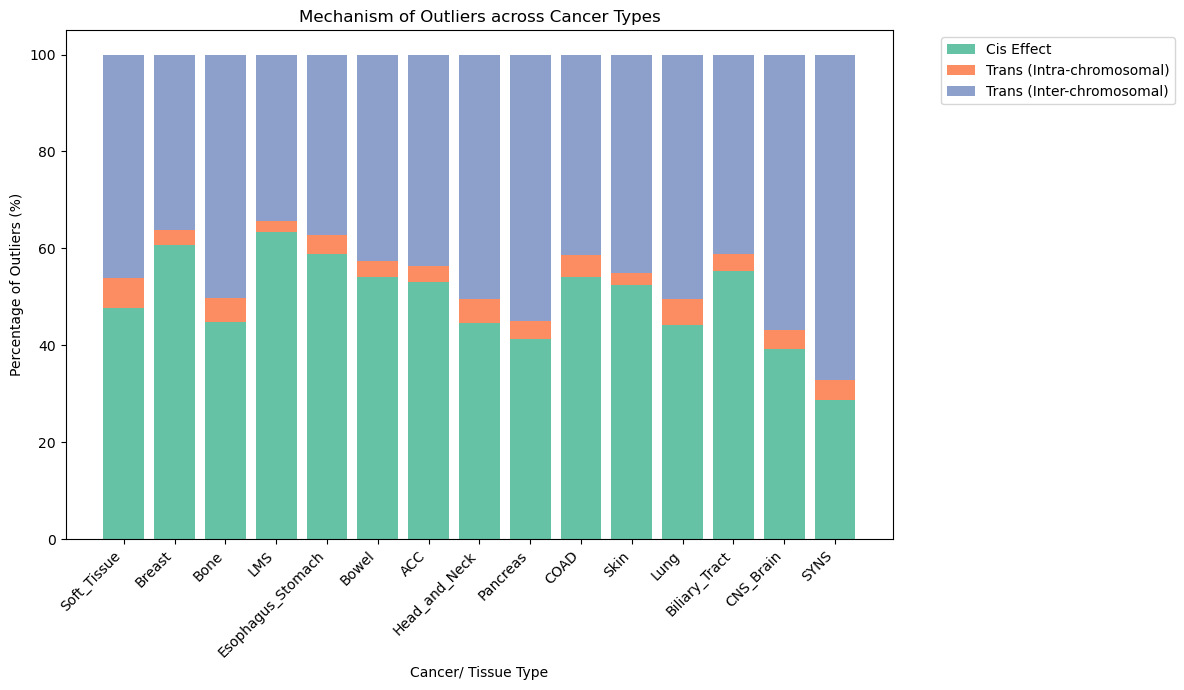

In [8]:
# note on cis and trans  not adding up to 100% => 
# cis pct is 'what % of outliers in a cancer were directly caused by a cnv on the same gene?', 
# trans pct is 'whenever a cnv driver+target pair were found in a sample, what % were they on different chromosomes?'or 'what % of trans effects were inter-chromosomal?'


plot_df = report_df.copy()
plot_df['Trans_Total'] = 100 - plot_df['Cis_Percent']
plot_df['Inter_Chrom_Trans'] = plot_df['Trans_Total'] * (plot_df['Trans_Chrom_Percent'] / 100)
plot_df['Intra_Chrom_Trans'] = plot_df['Trans_Total'] - plot_df['Inter_Chrom_Trans']

plt.figure(figsize=(12, 7))
categories = plot_df['Cancer']
cis = plot_df['Cis_Percent']
intra = plot_df['Intra_Chrom_Trans']
inter = plot_df['Inter_Chrom_Trans']

plt.bar(categories, cis, label='Cis Effect', color=sns.color_palette("Set2")[0])
plt.bar(categories, intra, bottom=cis, label='Trans (Intra-chromosomal)', color=sns.color_palette("Set2")[1])
plt.bar(categories, inter, bottom=cis+intra, label='Trans (Inter-chromosomal)', color=sns.color_palette("Set2")[2])

plt.xticks(rotation=45, ha='right')
plt.ylabel('Percentage of Outliers (%)')
plt.xlabel('Cancer/ Tissue Type')
plt.title('Mechanism of Outliers across Cancer Types')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [9]:
sns.color_palette("Set3")

[(0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
 (1.0, 1.0, 0.7019607843137254),
 (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
 (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
 (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
 (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
 (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
 (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
 (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
 (0.7372549019607844, 0.5019607843137255, 0.7411764705882353),
 (0.8, 0.9215686274509803, 0.7725490196078432),
 (1.0, 0.9294117647058824, 0.43529411764705883)]

/scratch/tmp/deben/ipykernel_2045623/4017775837.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_st.values, y=top_st.index, palette='Set2')


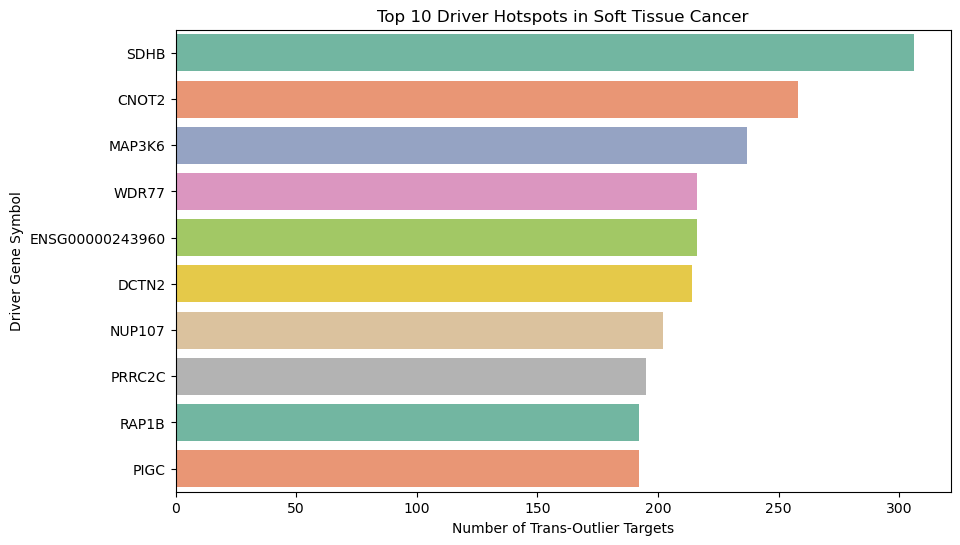

In [10]:
soft_tissue_drivers = all_drivers[all_drivers['Cancer'] == 'Soft_Tissue']
top_st = soft_tissue_drivers['Driver_Symbol'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_st.values, y=top_st.index, palette='Set2')
plt.title('Top 10 Driver Hotspots in Soft Tissue Cancer')
plt.xlabel('Number of Trans-Outlier Targets')
plt.ylabel('Driver Gene Symbol')
plt.show()


# for cancer in cancer_types:
#     driv = all_drivers[all_drivers['Cancer'] == cancer]
#     top_st = driv['Driver_Symbol'].value_counts().head(10)

#     plt.figure(figsize=(10, 6))
#     sns.barplot(x=top_st.values, y=top_st.index, palette='Set2')
#     plt.title(f'Top 10 Drivers in {cancer} Cancer')
#     plt.xlabel('Number of Targets (trans effect)')
#     plt.ylabel('Driver Gene Symbol')
#     plt.show()

In [ ]:
# todo: check logic/ change background 
def run_enrichment_for_driver(all_drivers, driver_symbol, gene_set='GO_Biological_Process_2023'):
    targets = all_drivers[all_drivers['Driver_Symbol'] == driver_symbol]['Target_Symbol'].unique().tolist()
    
    print(f"Running enrichment for {driver_symbol} ({len(targets)} targets)")
    
    enr = gp.enrichr(gene_list=targets,
                     gene_sets=gene_set,
                     organism='h. sapiens',
                     cutoff=0.05)
    
    results = enr.results
    return results[results['Adjusted P-value'] < 0.05].sort_values('Adjusted P-value')

st_enrichment = run_enrichment_for_driver(all_drivers[all_drivers['Cancer'] == 'Soft_Tissue'], 'SDHB')
print(st_enrichment[['Term', 'Overlap', 'Adjusted P-value']].head())

Running enrichment for SDHB (202 targets)


Empty DataFrame
Columns: [Term, Overlap, Adjusted P-value]
Index: []


In [31]:
def plot_genomic_circos_fast(
    drivers_df,
    title="Genomic Trans-Effects",
    outfile="genomic_circos.png",
    max_links=1000,
    score_col=None,   
    random_state=42
):
    plt.style.use("fast")  

    chrom_sizes = {
        '1': 249, '2': 243, '3': 198, '4': 191, '5': 181, '6': 171, '7': 159, '8': 145,
        '9': 138, '10': 133, '11': 135, '12': 133, '13': 115, '14': 107, '15': 102,
        '16': 90, '17': 81, '18': 78, '19': 59, '20': 63, '21': 48, '22': 51, 'X': 155, 'Y': 59
    }

    chrom_order = list(chrom_sizes.keys())
    total_len = sum(chrom_sizes.values())

    chrom_offsets = {}
    current_off = 0
    for chrom, size in chrom_sizes.items():
        chrom_offsets[chrom] = current_off
        current_off += size

    def get_theta(chrom, pos=0):
        chrom = str(chrom)
        if chrom not in chrom_offsets:
            return None
        return 2 * np.pi * (chrom_offsets[chrom] + pos) / total_len

    plot_data = drivers_df.copy()

    if score_col is not None and score_col in plot_data.columns:
        plot_data = plot_data.sort_values(score_col, ascending=False).head(max_links)
    else:
        plot_data = plot_data.sample(n=min(len(plot_data), max_links), random_state=random_state)

    fig = plt.figure(figsize=(10, 10), facecolor="white")
    ax = fig.add_subplot(111, projection='polar')
    ax.set_facecolor("white")

    palette = sns.color_palette("Set2", 8)
    chrom_colors = {chrom: palette[i % len(palette)] for i, chrom in enumerate(chrom_order)}

    for chrom, size in chrom_sizes.items():
        start = get_theta(chrom, 0)
        end = get_theta(chrom, size)
        theta_mid = (start + end) / 2

        ax.plot([start, end], [1.0, 1.0],
                lw=6, color=chrom_colors[chrom], alpha=0.95, solid_capstyle="butt")
        ax.text(theta_mid, 1.10, chrom, ha='center', va='center',
                fontsize=10, color="#333333")

    for _, row in plot_data.iterrows():
        theta1 = get_theta(row['driver_chrom'])
        theta2 = get_theta(row['target_chrom'])

        if theta1 is None or theta2 is None:
            continue

        t = np.linspace(theta1, theta2, 40)
        r = 0.96 - 0.9 * np.sin(np.linspace(0, np.pi, 40))
        color = chrom_colors.get(str(row['driver_chrom']), (0.7, 0.4, 0.4))
        ax.plot(t, r, color=color, alpha=0.12, lw=0.6)

    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.grid(False)
    ax.spines['polar'].set_visible(False)
    plt.title(title, fontsize=15, pad=42)
    plt.tight_layout()
    plt.show()
    plt.savefig(outfile, dpi=200, bbox_inches="tight", facecolor="white")
    plt.close()

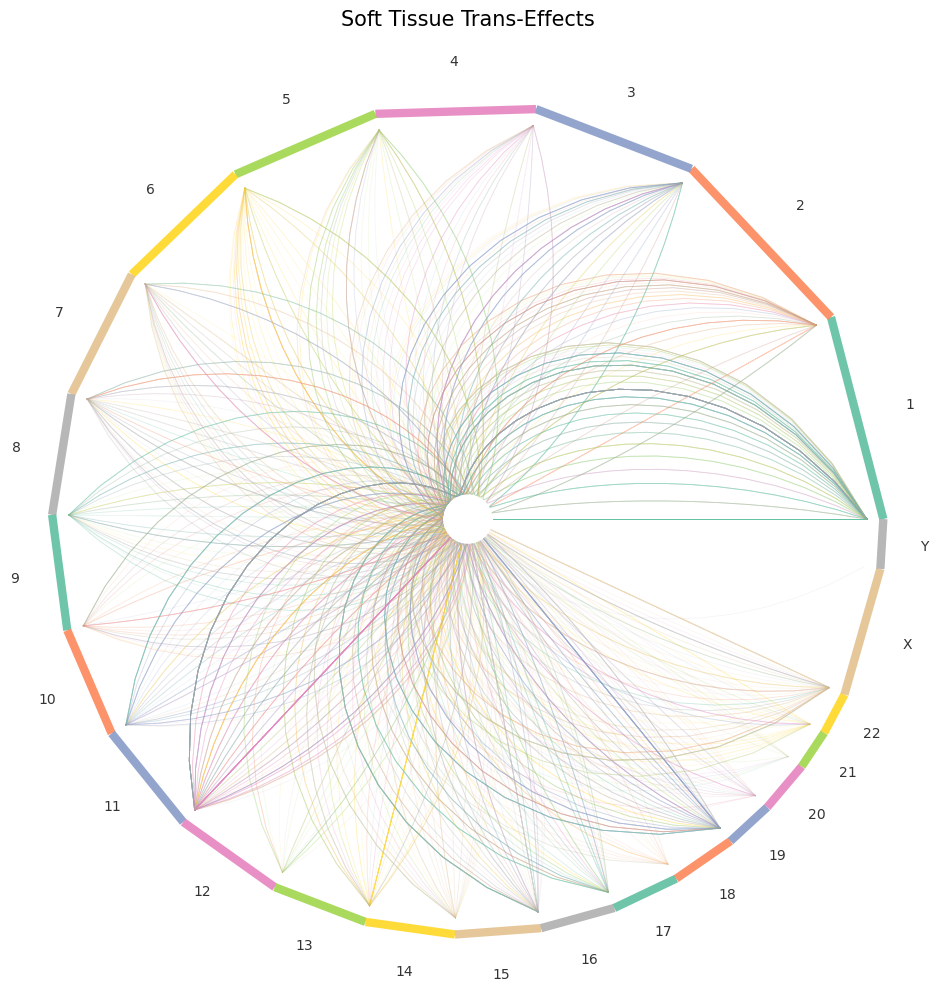

In [32]:
plot_genomic_circos_fast(
    all_drivers[all_drivers['Cancer'] == 'Soft_Tissue'],
    title="Soft Tissue Trans-Effects",
    max_links=1000,
    score_col="abs_effect"
)

In [37]:
def plot_single_driver_circos_agg(ax, df, driver_chrom, chrom_sizes, title=None, top_targets=20):
    chrom_order = list(chrom_sizes.keys())
    total_len = sum(chrom_sizes.values())

    chrom_offsets = {}
    current_off = 0
    for chrom, size in chrom_sizes.items():
        chrom_offsets[chrom] = current_off
        current_off += size

    def get_theta(chrom, pos=0):
        chrom = str(chrom)
        if chrom not in chrom_offsets:
            return None
        return 2 * np.pi * (chrom_offsets[chrom] + pos) / total_len

    palette = sns.color_palette("Set2", 8)
    chrom_colors = {chrom: palette[i % len(palette)] for i, chrom in enumerate(chrom_order)}

    for chrom, size in chrom_sizes.items():
        start = get_theta(chrom, 0)
        end = get_theta(chrom, size)
        mid = (start + end) / 2
        ax.plot([start, end], [1.0, 1.0], lw=5, color=chrom_colors[chrom], alpha=0.95)
        ax.text(mid, 1.10, chrom, ha='center', va='center', fontsize=8, color="#333333")

    pair_counts = (
        df.groupby(["driver_chrom", "target_chrom"])
          .size()
          .reset_index(name="count")
    )

    sub = pair_counts[pair_counts["driver_chrom"].astype(str) == str(driver_chrom)].copy()
    sub = sub.sort_values("count", ascending=False).head(top_targets)

    if len(sub) > 0:
        max_count = sub["count"].max()
        for _, row in sub.iterrows():
            theta1 = get_theta(row["driver_chrom"])
            theta2 = get_theta(row["target_chrom"])
            if theta1 is None or theta2 is None:
                continue

            t = np.linspace(theta1, theta2, 40)
            r = 0.97 - 0.12 * np.sin(np.linspace(0, np.pi, 40))

            scale = row["count"] / max_count
            lw = 0.6 + 3.0 * scale
            alpha = 0.12 + 0.45 * scale

            ax.plot(
                t, r,
                color=chrom_colors.get(str(row["target_chrom"]), (0.6, 0.6, 0.6)),
                alpha=alpha,
                lw=lw
            )

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(False)
    ax.spines["polar"].set_visible(False)
    ax.set_title(title or f"Driver chr{driver_chrom}", fontsize=11, pad=20)

def plot_top5_driver_chromosomes(drivers_df, cancer="Soft_Tissue", outfile="top5_driver_circos.png"):
    chrom_sizes = {
        '1': 249, '2': 243, '3': 198, '4': 191, '5': 181, '6': 171, '7': 159, '8': 145,
        '9': 138, '10': 133, '11': 135, '12': 133, '13': 115, '14': 107, '15': 102,
        '16': 90, '17': 81, '18': 78, '19': 59, '20': 63, '21': 48, '22': 51, 'X': 155, 'Y': 59
    }

    df = drivers_df.copy()
    if "Cancer" in df.columns:
        df = df[df["Cancer"] == cancer].copy()

    top5 = (
        df["driver_chrom"]
        .astype(str)
        .value_counts()
        .head(5)
        .index
        .tolist()
    )

    fig, axes = plt.subplots(
        2, 3,
        figsize=(16, 10),
        subplot_kw={"projection": "polar"},
        facecolor="white"
    )
    axes = axes.flatten()

    for i, chrom in enumerate(top5):
        n_links = (df["driver_chrom"].astype(str) == str(chrom)).sum()
        plot_single_driver_circos(
            axes[i],
            df,
            driver_chrom=chrom,
            chrom_sizes=chrom_sizes,
            title=f"Driver chr{chrom} (n={n_links})",
            max_links=300
        )

    # sixth panel = overall counts text or blank
    axes[5].axis("off")
    axes[5].text(
        0.5, 0.5,
        "Top 5 driver chromosomes\nshown separately",
        ha="center", va="center",
        transform=axes[5].transAxes,
        fontsize=14, color="#444444"
    )

    fig.suptitle(f"{cancer.replace('_', ' ')}: Top 5 Driver Chromosomes", fontsize=18, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    plt.savefig(outfile, dpi=220, bbox_inches="tight", facecolor="white")
    plt.close()

In [42]:
def plot_top5_driver_circos_aggregated(
    drivers_df,
    cancer="Soft_Tissue",
    outfile="soft_tissue_top5_driver_circos_aggregated.png",
    top_n_drivers=5,
    top_n_targets=20,
    figsize=(16, 10)
):
    chrom_sizes = {
        '1': 249, '2': 243, '3': 198, '4': 191, '5': 181, '6': 171, '7': 159, '8': 145,
        '9': 138, '10': 133, '11': 135, '12': 133, '13': 115, '14': 107, '15': 102,
        '16': 90, '17': 81, '18': 78, '19': 59, '20': 63, '21': 48, '22': 51, 'X': 155, 'Y': 59
    }
    chrom_order = list(chrom_sizes.keys())
    total_len = sum(chrom_sizes.values())

    df = drivers_df.copy()
    df["driver_chrom"] = df["driver_chrom"].astype(str)
    df["target_chrom"] = df["target_chrom"].astype(str)

    if "Cancer" in df.columns and cancer is not None:
        df = df[df["Cancer"] == cancer].copy()

    df = df[
        df["driver_chrom"].isin(chrom_order) &
        df["target_chrom"].isin(chrom_order)
    ].copy()

    chrom_offsets = {}
    current_off = 0
    for chrom, size in chrom_sizes.items():
        chrom_offsets[chrom] = current_off
        current_off += size

    def get_theta(chrom, pos=0):
        chrom = str(chrom)
        if chrom not in chrom_offsets:
            return None
        return 2 * np.pi * (chrom_offsets[chrom] + pos) / total_len

    palette = sns.color_palette("Set2", 8)
    chrom_colors = {
        chrom: palette[i % len(palette)]
        for i, chrom in enumerate(chrom_order)
    }

    driver_counts = (
        df.groupby("driver_chrom")
          .size()
          .reset_index(name="n")
          .sort_values("n", ascending=False)
    )
    top_drivers = driver_counts.head(top_n_drivers)["driver_chrom"].tolist()

    pair_counts = (
        df.groupby(["driver_chrom", "target_chrom"])
          .size()
          .reset_index(name="count")
    )

    ncols = 3
    nrows = int(np.ceil(top_n_drivers / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        subplot_kw={"projection": "polar"},
        facecolor="white"
    )
    axes = np.array(axes).reshape(-1)

    def draw_panel(ax, driver_chrom):
        for chrom, size in chrom_sizes.items():
            start = get_theta(chrom, 0)
            end = get_theta(chrom, size)
            mid = (start + end) / 2

            ax.plot(
                [start, end], [1.0, 1.0],
                lw=5, color=chrom_colors[chrom], alpha=0.95, solid_capstyle="butt"
            )
            ax.text(
                mid, 1.10, chrom,
                ha="center", va="center",
                fontsize=8, color="#333333"
            )

        sub = pair_counts[pair_counts["driver_chrom"] == str(driver_chrom)].copy()
        sub = sub.sort_values("count", ascending=False).head(top_n_targets)

        if len(sub) > 0:
            max_count = sub["count"].max()

            for _, row in sub.iterrows():
                theta1 = get_theta(row["driver_chrom"])
                theta2 = get_theta(row["target_chrom"])
                if theta1 is None or theta2 is None:
                    continue

                t = np.linspace(theta1, theta2, 60)
                r = 0.965 - 0.9 * np.sin(np.linspace(0, np.pi, 60))

                scale = row["count"] / max_count
                lw = 0.8 + 3.2 * scale
                alpha = 0.18 + 0.45 * scale

                ax.plot(
                    t, r,
                    color=chrom_colors.get(str(row["target_chrom"]), (0.6, 0.6, 0.6)),
                    alpha=alpha,
                    lw=lw
                )

        total_n = int(driver_counts.loc[driver_counts["driver_chrom"] == str(driver_chrom), "n"].iloc[0])

        ax.set_title(f"Driver chr{driver_chrom} (n={total_n})", fontsize=11, pad=20)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(False)
        ax.spines["polar"].set_visible(False)
        ax.set_facecolor("white")

    for i, driver_chrom in enumerate(top_drivers):
        draw_panel(axes[i], driver_chrom)

    for j in range(len(top_drivers), len(axes)):
        axes[j].axis("off")

    pretty_cancer = cancer.replace("_", " ") if isinstance(cancer, str) else "All cancers"
    fig.suptitle(
        f"{pretty_cancer}: Top {top_n_drivers} Driver Chromosomes",
        fontsize=18,
        y=0.98
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    plt.savefig(outfile, dpi=220, bbox_inches="tight", facecolor="white")
    plt.close()

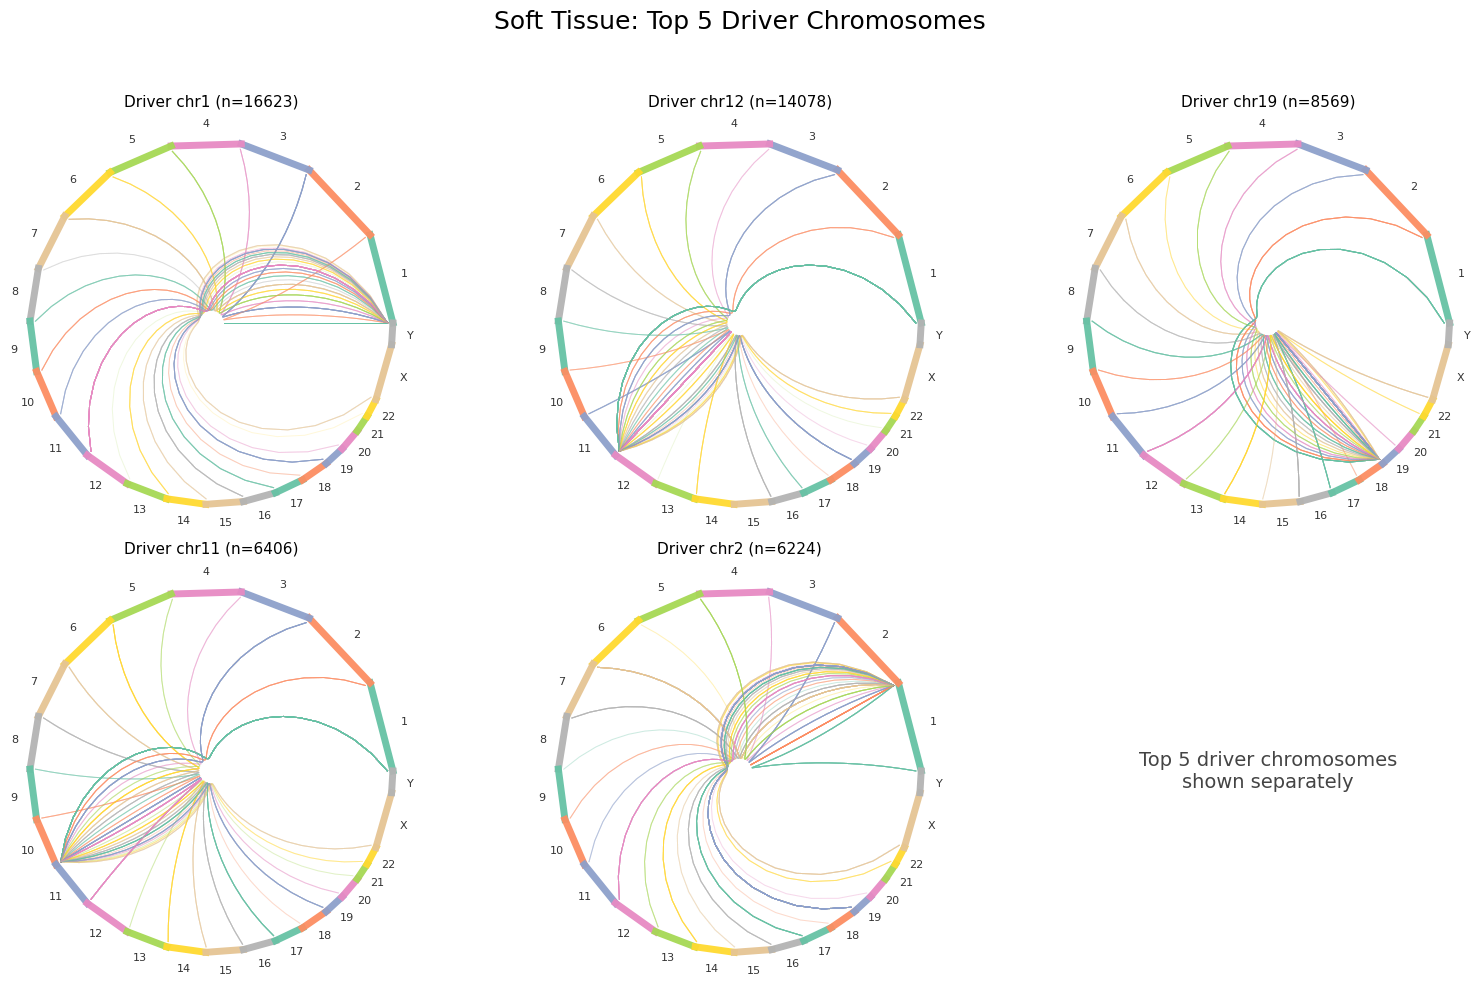

In [ ]:
plot_top5_driver_chromosomes(
    all_drivers,
    cancer="Soft_Tissue",
    outfile="soft_tissue_top5_driver_circos.png"
)

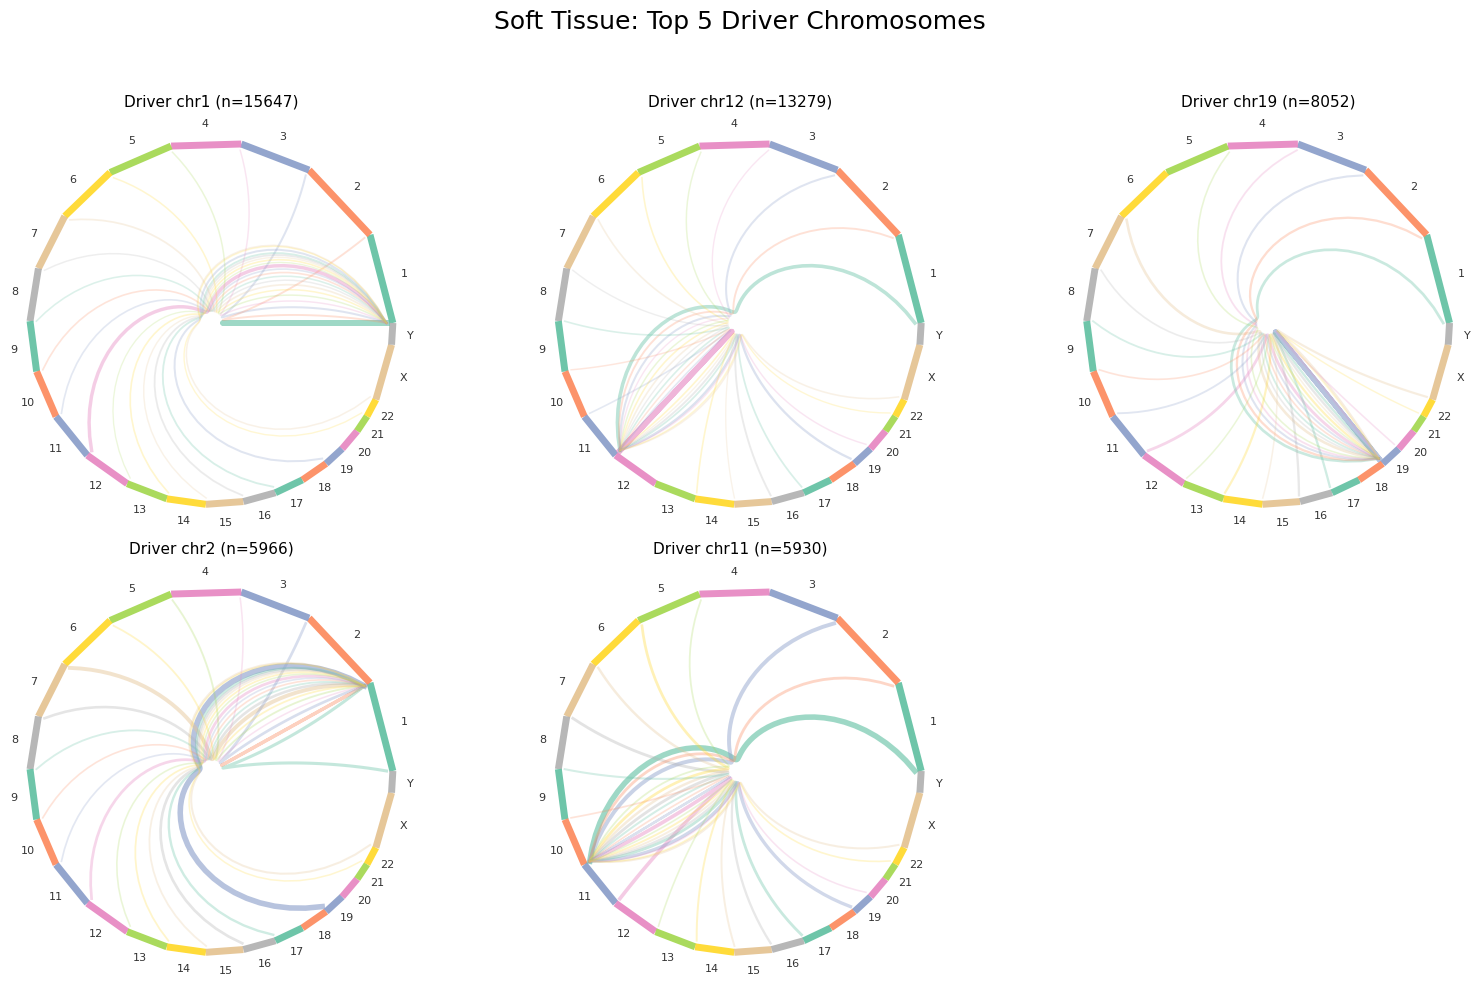

In [43]:
plot_top5_driver_circos_aggregated(
    all_drivers,
    cancer="Soft_Tissue",
    outfile="soft_tissue_top5_driver_circos_aggregated.png"
)

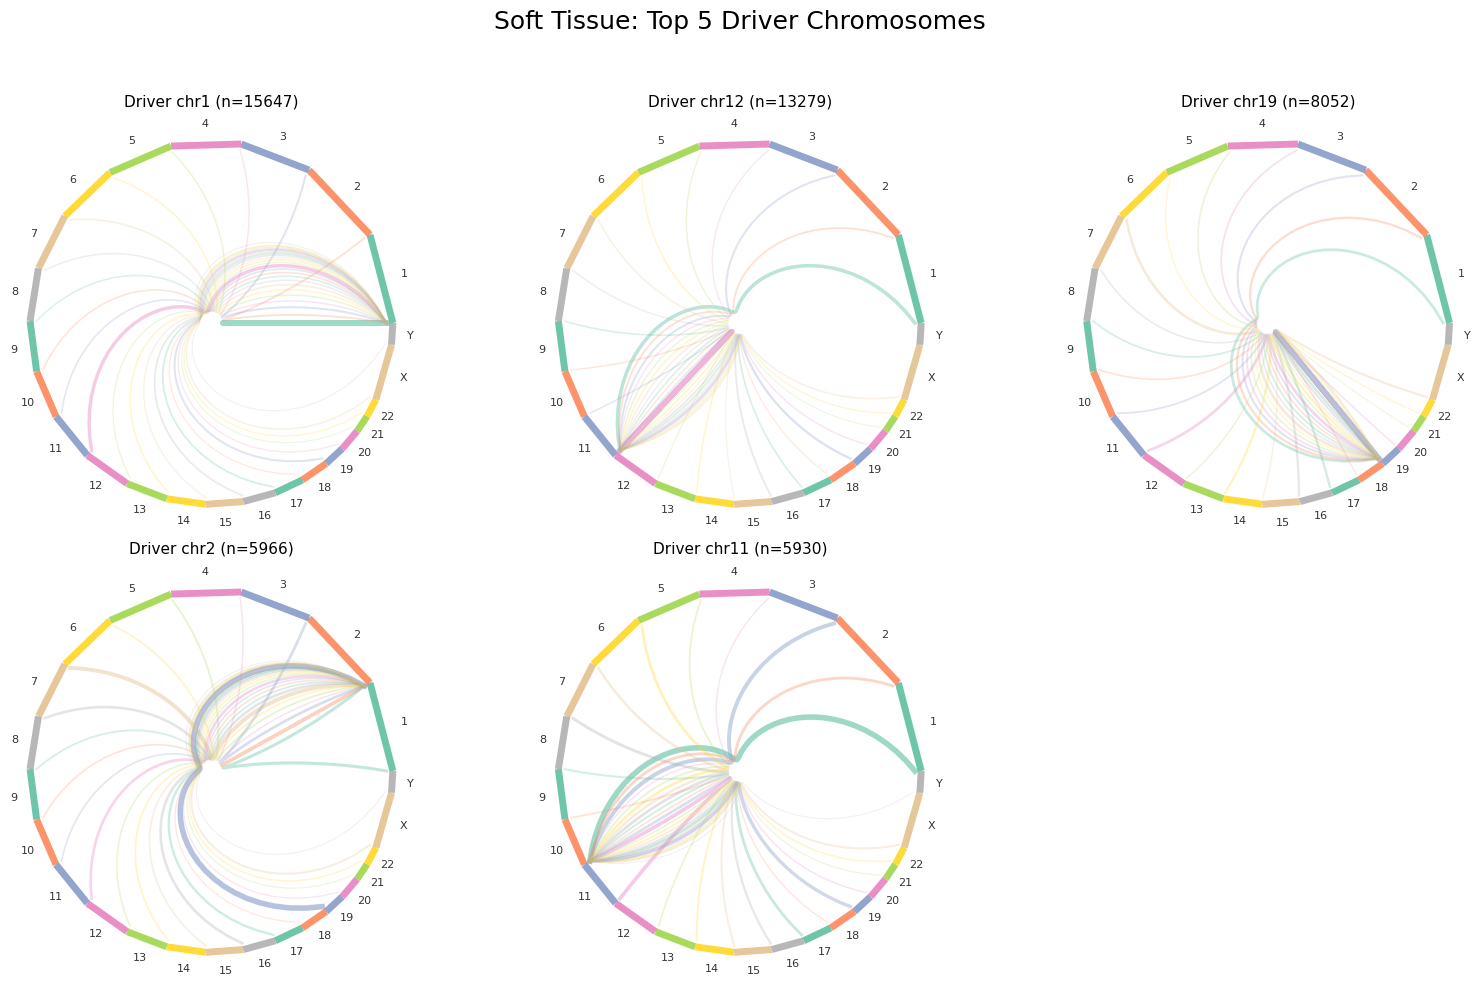

In [44]:
plot_top5_driver_circos_aggregated(
    all_drivers,
    cancer="Soft_Tissue",
    outfile="soft_tissue_top5_driver_circos_aggregated.png",
    top_n_drivers=5,
    top_n_targets=30
)